# Anomaly Clustering

Cluster anomalies detected by Transformer+OC-SVM, PNN (spoofing gain), and PRAE (RFDR).

In [25]:
import os
import sys
import glob
import json
import logging
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences, load_processed
from detection.data.preprocessing import get_time_frac, assign_period
from detection.models import hybrid, pnn as pnn_module, prae as prae_module
from detection.models.transformer import BottleneckTransformer
from detection.spoofing.gain import compute_spoofing_gains_batch
from detection.thresholds.rfdr import RollingFalseDiscoveryRate
from detection.trainers.factory import load_model

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger(__name__)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
TRAIN_YEAR = 2015
# Subsample mode: set to None to use full data
MAX_ROWS = None  # rows per file (must be > SEQ_LENGTH)

DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
RESULTS_DIR = os.path.join("..", "results", str(TRAIN_YEAR))
OUTPUT_DIR = os.path.join("..", "results", str(TRAIN_YEAR), "test_output")
MODEL_TYPES = ["transformer_ocsvm", "pnn", "prae"]

FILES_2010 = sorted(glob.glob(os.path.join(DATA_DIR, "2010-*.parquet")))
FILES_2015 = sorted(glob.glob(os.path.join(DATA_DIR, "2015-*.parquet")))
FILES_2017 = sorted(glob.glob(os.path.join(DATA_DIR, "2017-*.parquet")))
TEST_FILES = [FILES_2010[0], FILES_2010[1], FILES_2010[2], FILES_2010[-3], FILES_2010[-2], FILES_2010[-1],
                FILES_2015[-3], FILES_2015[-2], FILES_2015[-1], 
                FILES_2017[0], FILES_2017[1], FILES_2017[2], FILES_2017[-3], FILES_2017[-2], FILES_2017[-1]]

SEQ_LENGTH = 25
BATCH_SIZE = 64

LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [
        ("bid", "price"),
        ("bid", "volume"),
        ("ask", "price"),
        ("ask", "volume"),
    ]
]

SPOOF_Q = 4500
SPOOF_q = 100
SPOOF_DELTA_A = 0.0
SPOOF_DELTA_B = 0.01
SPOOF_FEES = {"maker": 0.0, "taker": 0.05}

RFDR_WINDOW = 500
RFDR_ALPHA = 0.05

PERIODS = {
    "1st_hour": (9.0, 10.0),
    "rest_of_morning": (10.0, 12.0),
    "afternoon": (12.0, 15.5),
    "american_open": (15.5, 17.5),
}

HDBSCAN_MIN_CLUSTER_FRAC = 20  # min_cluster_size = max(5, n_anom // this)
HDBSCAN_MAX_CLUSTER_SIZE = 500  # hard cap to avoid OOM on large anomaly sets
HDBSCAN_MIN_SAMPLES = 15       # explicit min_samples, kept small to avoid OOM
RANDOM_STATE = 42

# Check for pre-computed results from test.py / testing notebook
_saved_meta_path = os.path.join(OUTPUT_DIR, "test_meta.json")
SAVED_RESULTS_AVAILABLE = (
    os.path.exists(_saved_meta_path)
    and all(os.path.exists(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy")) for mt in MODEL_TYPES)
)
if SAVED_RESULTS_AVAILABLE:
    with open(_saved_meta_path) as _f:
        _saved_meta = json.load(_f)
    _saved_files = set(_saved_meta.get("test_files", []))
    _current_files = {os.path.basename(f) for f in TEST_FILES}
    # Only use saved results if the test files are a superset (saved includes current)
    SAVED_RESULTS_AVAILABLE = _current_files.issubset(_saved_files) and MAX_ROWS is None
    if SAVED_RESULTS_AVAILABLE:
        print(f"Pre-computed results found in {OUTPUT_DIR}. Will load scores & preds.")
    else:
        print(f"Pre-computed results exist but test files differ or MAX_ROWS set. Will recompute.")
else:
    print("No pre-computed results found. Will compute from scratch.")


Pre-computed results found in ..\results\2015\test_output. Will load scores & preds.


In [27]:
feature_names_map = {}
for mt in MODEL_TYPES:
    feat_path = os.path.join(RESULTS_DIR, f"{mt}_features.txt")
    if os.path.exists(feat_path):
        with open(feat_path) as fh:
            feature_names_map[mt] = [ln.strip() for ln in fh if ln.strip()]
    else:
        _, tmp = load_processed(TEST_FILES[0], "xltime", LOB_COLUMNS)
        feature_names_map[mt] = tmp.columns.tolist()

if not SAVED_RESULTS_AVAILABLE:
    loaded_models = {}
    loaded_scalers = {}
    for model_type in MODEL_TYPES:
        feat_names = feature_names_map[model_type]
        weights_path = os.path.join(RESULTS_DIR, f"{model_type}_weights.pth")
        model, ocsvm = load_model(model_type, len(feat_names), weights_path, DEVICE, SEQ_LENGTH)
        loaded_models[model_type] = (model, ocsvm)

        scaler_path = os.path.join(RESULTS_DIR, f"{model_type}_scaler.pkl")
        loaded_scalers[model_type] = (
            joblib.load(scaler_path) if os.path.exists(scaler_path) else MinMaxScaler()
        )
    print("Models & scalers loaded.")
else:
    print("Skipping model loading (using pre-computed results).")

Skipping model loading (using pre-computed results).


In [28]:
def _load_and_slice(filepath, time_col, lob_cols, max_rows=None):
    df, feats = load_processed(filepath, time_col, lob_cols)
    if max_rows is not None:
        df = df.iloc[:max_rows].reset_index(drop=True)
        feats = feats.iloc[:max_rows].reset_index(drop=True)
    return df, feats


if SAVED_RESULTS_AVAILABLE:
    with open(os.path.join(OUTPUT_DIR, "test_meta.json")) as f:
        saved_meta = json.load(f)

    saved_day_names = saved_meta["day_names"]
    saved_boundaries = saved_meta["day_boundaries"]
    current_basenames = [os.path.basename(f) for f in TEST_FILES]

    # Find which saved days match our TEST_FILES
    day_indices = [i for i, dn in enumerate(saved_day_names) if dn in current_basenames]

    if set(current_basenames) == set(saved_day_names):
        # Exact match - load everything directly
        all_scores = {}
        all_preds = {}
        for mt in MODEL_TYPES:
            all_scores[mt] = np.load(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy"))
            all_preds[mt] = np.load(os.path.join(OUTPUT_DIR, f"{mt}_preds.npy"))
        period_labels_seq = np.load(os.path.join(OUTPUT_DIR, "period_labels.npy"), allow_pickle=True)
        day_boundaries = saved_boundaries
    else:
        # Subset - slice out only the days we need
        all_scores = {mt: [] for mt in MODEL_TYPES}
        all_preds = {mt: [] for mt in MODEL_TYPES}
        period_labels_parts = []
        day_boundaries = [0]
        full_scores = {mt: np.load(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy")) for mt in MODEL_TYPES}
        full_preds = {mt: np.load(os.path.join(OUTPUT_DIR, f"{mt}_preds.npy")) for mt in MODEL_TYPES}
        full_periods = np.load(os.path.join(OUTPUT_DIR, "period_labels.npy"), allow_pickle=True)
        for di in day_indices:
            lo = saved_boundaries[di]
            hi = saved_boundaries[di + 1]
            for mt in MODEL_TYPES:
                all_scores[mt].append(full_scores[mt][lo:hi])
                all_preds[mt].append(full_preds[mt][lo:hi])
            period_labels_parts.append(full_periods[lo:hi])
            day_boundaries.append(day_boundaries[-1] + (hi - lo))
        for mt in MODEL_TYPES:
            all_scores[mt] = np.concatenate(all_scores[mt])
            all_preds[mt] = np.concatenate(all_preds[mt])
        period_labels_seq = np.concatenate(period_labels_parts)

    # Rebuild feat_values_seq from raw files
    all_feat_values = []
    for test_file in TEST_FILES:
        _, features_day = _load_and_slice(test_file, "xltime", LOB_COLUMNS, MAX_ROWS)
        n_seq = len(features_day) - SEQ_LENGTH
        if n_seq > 0:  # Only process if file has enough data
            all_feat_values.append(features_day.iloc[SEQ_LENGTH: SEQ_LENGTH + n_seq].reset_index(drop=True))
    feat_values_seq = pd.concat(all_feat_values, ignore_index=True)
    n_total = len(next(iter(all_scores.values())))
    logger.info("Loaded pre-computed results: %d samples from %d files.", n_total, len(TEST_FILES))

else:
    # Compute from scratch
    all_scores = {mt: [] for mt in MODEL_TYPES}
    all_preds = {mt: [] for mt in MODEL_TYPES}
    all_period_labels = []
    all_feat_values = []
    day_boundaries = [0]

    for test_file in TEST_FILES:
        df_day, features_day = _load_and_slice(test_file, "xltime", LOB_COLUMNS, MAX_ROWS)
        time_frac_day = get_time_frac(df_day)[: len(features_day)]
        period_labels = assign_period(time_frac_day, PERIODS)
        spread_raw = (df_day["ask-price-1"] - df_day["bid-price-1"]).values
        n_seq = len(features_day) - SEQ_LENGTH
        
        # Skip files with insufficient data
        if n_seq <= 0:
            logger.warning(
                f"File {os.path.basename(test_file)} too small ({len(features_day)} rows, "
                f"need > {SEQ_LENGTH}). Skipping."
            )
            continue

        all_period_labels.append(period_labels[SEQ_LENGTH : SEQ_LENGTH + n_seq])
        all_feat_values.append(
            features_day.iloc[SEQ_LENGTH : SEQ_LENGTH + n_seq].reset_index(drop=True)
        )

        for model_type in MODEL_TYPES:
            logger.info(f"Processing {model_type} for file {os.path.basename(test_file)}")
            feat_names = feature_names_map[model_type]
            scaler = loaded_scalers[model_type]
            model, ocsvm = loaded_models[model_type]

            feat_df = features_day.copy()
            for col in feat_names:
                if col not in feat_df.columns:
                    feat_df[col] = 0.0
            feat_df = feat_df[feat_names]

            scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
            sequences = create_sequences(scaled, SEQ_LENGTH)

            if model_type == "transformer_ocsvm":
                x_tensor = torch.tensor(sequences, dtype=torch.float32)
                loader = DataLoader(
                    TensorDataset(x_tensor, x_tensor), batch_size=BATCH_SIZE, shuffle=False
                )
                if ocsvm is not None:
                    detector = hybrid.TransformerOCSVM.__new__(hybrid.TransformerOCSVM)
                    detector.transformer = model
                    detector.ocsvm = ocsvm
                    scores = detector.predict(loader)
                else:
                    scores_list = []
                    with torch.no_grad():
                        for batch in loader:
                            x = batch[0].to(DEVICE)
                            rec = model(x)
                            scores_list.append(
                                torch.mean((x - rec) ** 2, dim=(1, 2)).cpu().numpy()
                            )
                    scores = np.concatenate(scores_list)
                preds = (scores > 0).astype(int)

            elif model_type == "pnn":
                all_mu, all_sigma, all_alpha = [], [], []
                with torch.no_grad():
                    for start in range(0, len(sequences), BATCH_SIZE):
                        end = min(start + BATCH_SIZE, len(sequences))
                        x_b = torch.tensor(
                            np.ascontiguousarray(sequences[start:end]), dtype=torch.float32
                        )
                        x_b = x_b.reshape(end - start, -1).to(DEVICE)
                        mu, sigma, alpha = model(x_b)
                        all_mu.append(mu.cpu().numpy().flatten())
                        all_sigma.append(sigma.cpu().numpy().flatten())
                        all_alpha.append(alpha.cpu().numpy().flatten())

                mu_arr = np.concatenate(all_mu)
                sigma_arr = np.concatenate(all_sigma)
                alpha_arr = np.concatenate(all_alpha)

                spread_seq = spread_raw[SEQ_LENGTH : SEQ_LENGTH + len(mu_arr)]
                if len(spread_seq) < len(mu_arr):
                    spread_seq = np.pad(
                        spread_seq, (0, len(mu_arr) - len(spread_seq)), mode="edge"
                    )
                spread_seq = np.where(np.abs(spread_seq) > 0, np.abs(spread_seq), 1e-4)

                scores = compute_spoofing_gains_batch(
                    mu_arr, sigma_arr, alpha_arr, spread_seq,
                    delta_a=SPOOF_DELTA_A, delta_b=SPOOF_DELTA_B,
                    Q=SPOOF_Q, q=SPOOF_q,
                    fees=SPOOF_FEES, side="ask",
                )
                preds = (scores > 0).astype(int)

            else:
                x_tensor = torch.tensor(sequences, dtype=torch.float32)
                loader = DataLoader(
                    TensorDataset(x_tensor, x_tensor), batch_size=BATCH_SIZE, shuffle=False
                )
                scores_list = []
                with torch.no_grad():
                    for batch in loader:
                        x = batch[0].to(DEVICE)
                        rec, _ = model(x, training=False)
                        scores_list.append(
                            torch.sum((x - rec) ** 2, dim=tuple(range(1, x.dim())))
                            .cpu()
                            .numpy()
                        )
                scores = np.concatenate(scores_list)

                rfdr = RollingFalseDiscoveryRate(window_size=RFDR_WINDOW, alpha=RFDR_ALPHA)
                preds = np.zeros(len(scores), dtype=int)
                for i, s in enumerate(scores):
                    is_anom, _ = rfdr.process_new_score(float(s))
                    preds[i] = int(is_anom)

            all_scores[model_type].append(scores)
            all_preds[model_type].append(preds)

        day_boundaries.append(day_boundaries[-1] + n_seq)

    for mt in MODEL_TYPES:
        all_scores[mt] = np.concatenate(all_scores[mt])
        all_preds[mt] = np.concatenate(all_preds[mt])

    period_labels_seq = np.concatenate(all_period_labels)
    feat_values_seq = pd.concat(all_feat_values, ignore_index=True)
    n_total = len(next(iter(all_scores.values())))

2026-03-25 10:27:10,105 | INFO | Loaded pre-computed results: 7138216 samples from 15 files.


In [29]:
pred_matrix = np.column_stack([all_preds[mt][:n_total] for mt in MODEL_TYPES])
n_models_flagged = pred_matrix.sum(axis=1)
anom_indices = np.where(n_models_flagged >= 1)[0]
n_anom_total = len(anom_indices)

score_matrix_raw = np.column_stack([all_scores[mt][anom_indices] for mt in MODEL_TYPES])
feat_anom = feat_values_seq.iloc[anom_indices].reset_index(drop=True)
period_anom = period_labels_seq[anom_indices]
preds_anom = {mt: all_preds[mt][anom_indices] for mt in MODEL_TYPES}

In [30]:
# Save all preds and all scores for potential future use
if not SAVED_RESULTS_AVAILABLE:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    for mt in MODEL_TYPES:
        np.save(os.path.join(OUTPUT_DIR, f"{mt}_scores.npy"), all_scores[mt][:n_total])
        np.save(os.path.join(OUTPUT_DIR, f"{mt}_preds.npy"), all_preds[mt][:n_total])
    np.save(os.path.join(OUTPUT_DIR, "period_labels.npy"), period_labels_seq[:n_total])
    with open(os.path.join(OUTPUT_DIR, "test_meta.json"), "w") as f:
        json.dump({
            "test_files": [os.path.basename(f) for f in TEST_FILES],
            "day_names": [os.path.basename(f) for f in TEST_FILES],
            "day_boundaries": day_boundaries,
        }, f)
    logger.info(f"Saved computed scores & preds to {OUTPUT_DIR}.")

In [31]:
print(f"Total anomalies: {n_anom_total} / {n_total} ({100 * n_anom_total / n_total:.2f}%)")
print()
for mt in MODEL_TYPES:
    n_mt = int(all_preds[mt][:n_total].sum())
    print(f"  {mt:25s}: {n_mt:6d} anomalies ({100 * n_mt / n_total:.2f}%)")


Total anomalies: 217843 / 7138216 (3.05%)

  transformer_ocsvm        :   6494 anomalies (0.09%)
  pnn                      :   7856 anomalies (0.11%)
  prae                     : 204029 anomalies (2.86%)


In [32]:
score_scalers = {}
score_matrix_full_norm = np.zeros((n_total, len(MODEL_TYPES)), dtype=np.float32)

for j, mt in enumerate(MODEL_TYPES):
    sc = MinMaxScaler()
    score_matrix_full_norm[:, j] = sc.fit_transform(
        all_scores[mt][:n_total].reshape(-1, 1)
    ).flatten()
    score_scalers[mt] = sc

score_matrix_norm = score_matrix_full_norm[anom_indices]
SCORE_COLS = ["ocsvm_norm", "pnn_norm", "prae_norm"]
score_df = pd.DataFrame(score_matrix_norm, columns=SCORE_COLS)
display(score_df.describe().round(4))

,ocsvm_norm,pnn_norm,prae_norm
count,217843.0000,217843.0000,217843.0000
mean,0.4213,0.9967,0.0773
std,0.1899,0.0223,0.0861
min,0.0024,0.0000,0.0001
25%,0.2581,1.0000,0.0171
50%,0.4104,1.0000,0.0350
75%,0.5551,1.0000,0.1230
max,1.0000,1.0000,1.0000


In [33]:
X_clust = score_df.values

In [34]:
min_cluster_size = max(5, min(HDBSCAN_MAX_CLUSTER_SIZE, n_anom_total // HDBSCAN_MIN_CLUSTER_FRAC))
hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size, min_samples=HDBSCAN_MIN_SAMPLES)
cluster_labels = hdbscan_model.fit_predict(X_clust)

unique_clusters = sorted(set(cluster_labels))
n_hdb_clusters = len(unique_clusters) - (1 if -1 in unique_clusters else 0)
n_noise = int((cluster_labels == -1).sum())

# Silhouette & Davies-Bouldin (excluding noise)
mask_valid = cluster_labels != -1
if mask_valid.sum() >= 2 and n_hdb_clusters >= 2:
    sil = silhouette_score(X_clust[mask_valid], cluster_labels[mask_valid])
    db = davies_bouldin_score(X_clust[mask_valid], cluster_labels[mask_valid])
else:
    sil, db = np.nan, np.nan

print(f"HDBSCAN: {n_hdb_clusters} clusters, {n_noise} noise points ({100*n_noise/n_anom_total:.1f}%)")
print(f"  Silhouette (excl. noise): {sil:.4f}")
print(f"  Davies-Bouldin (excl. noise): {db:.4f}")

# Build cluster names with PNN detection rate
pnn_rates = {}
for c in unique_clusters:
    mask = cluster_labels == c
    pnn_rates[c] = preds_anom["pnn"][mask].mean() if mask.sum() > 0 else 0.0

cluster_names = {}
for c in unique_clusters:
    if c == -1:
        cluster_names[c] = f"Noise (n={(cluster_labels == c).sum()})"
    else:
        rate = pnn_rates[c]
        cluster_names[c] = f"C{c} (PNN rate={rate:.1%})"

mapping_df = pd.DataFrame(
    {
        "cluster": [cluster_names[c] for c in unique_clusters],
        "size": [(cluster_labels == c).sum() for c in unique_clusters],
        "pnn_rate": [round(pnn_rates[c], 4) for c in unique_clusters],
    }
)
display(mapping_df)


HDBSCAN: 3 clusters, 21386 noise points (9.8%)
  Silhouette (excl. noise): 0.3284
  Davies-Bouldin (excl. noise): 0.3825


,cluster,size,pnn_rate
0,Noise (n=21386),21386,0.0053
1,C0 (PNN rate=0.2%),630,0.0016
2,C1 (PNN rate=4.1%),189368,0.0409
3,C2 (PNN rate=0.0%),6459,0.0000


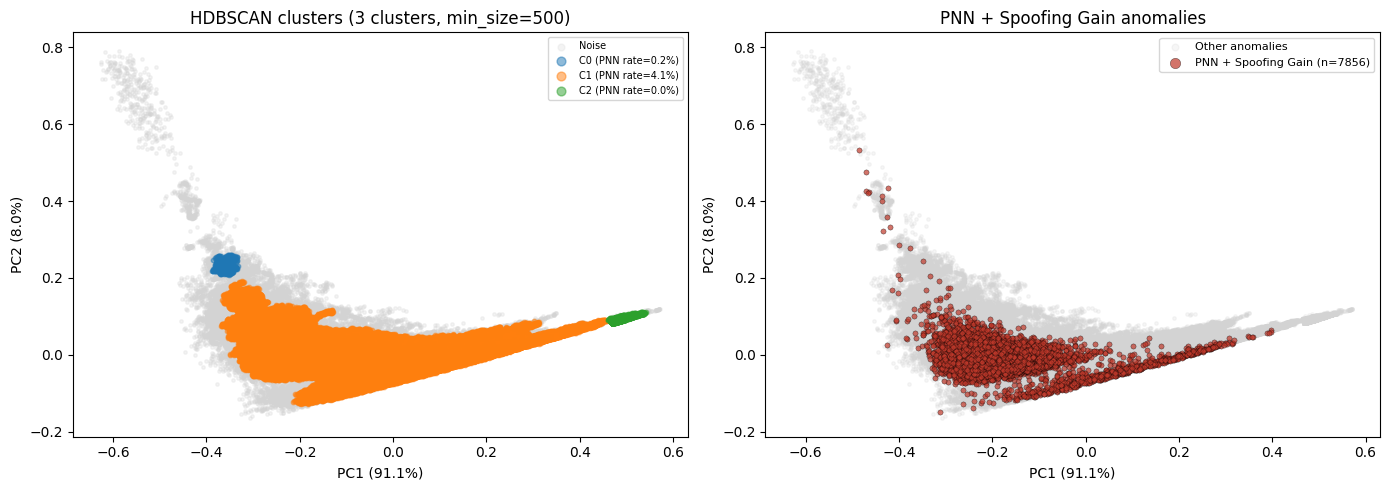

In [35]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_clust)

CLUSTER_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left panel: HDBSCAN clusters ---
for c in unique_clusters:
    mask = cluster_labels == c
    if c == -1:
        axes[0].scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=6, alpha=0.25, color="lightgrey", label="Noise",
        )
    else:
        axes[0].scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            s=10, alpha=0.5,
            color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
            label=cluster_names[c],
        )
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title(f"HDBSCAN clusters ({n_hdb_clusters} clusters, min_size={min_cluster_size})")
axes[0].legend(fontsize=7, markerscale=2)

# Right panel: PNN + Spoofing Gain overlay
pnn_mask = preds_anom["pnn"].astype(bool)
non_pnn_mask = ~pnn_mask

axes[1].scatter(
    X_pca[non_pnn_mask, 0], X_pca[non_pnn_mask, 1],
    s=6, alpha=0.2, color="lightgrey", label="Other anomalies",
)
axes[1].scatter(
    X_pca[pnn_mask, 0], X_pca[pnn_mask, 1],
    s=14, alpha=0.7, color="#c0392b", edgecolors="black", linewidths=0.3,
    label=f"PNN + Spoofing Gain (n={pnn_mask.sum()})",
)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("PNN + Spoofing Gain anomalies")
axes[1].legend(fontsize=8, markerscale=2)

plt.tight_layout()
plt.show()

,N,Share (%),ocsvm_score_mean,ocsvm_det_rate,pnn_score_mean,pnn_det_rate,prae_score_mean,prae_det_rate
Cluster,,,,,,,,
Noise (n=21386),21386,9.82,0.2883,0.0020,0.9687,0.0053,0.1586,0.9934
C0 (PNN rate=0.2%),630,0.29,0.1579,0.0000,1.0000,0.0016,0.4170,0.9984
C1 (PNN rate=4.1%),189368,86.93,0.4206,0.0000,0.9998,0.0409,0.0695,0.9617
C2 (PNN rate=0.0%),6459,2.96,0.9082,0.9988,1.0000,0.0000,0.0044,0.0062


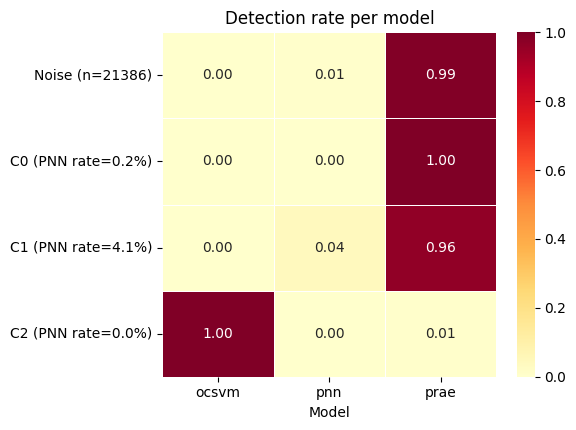

In [36]:
profile_rows = []
for c in unique_clusters:
    mask = cluster_labels == c
    row = {
        "Cluster": cluster_names[c],
        "N": int(mask.sum()),
        "Share (%)": round(100 * mask.sum() / n_anom_total, 2),
    }
    for j, mt in enumerate(MODEL_TYPES):
        short = mt.replace("transformer_ocsvm", "ocsvm")
        row[f"{short}_score_mean"] = round(float(score_matrix_norm[mask, j].mean()), 4)
        row[f"{short}_det_rate"] = round(float(preds_anom[mt][mask].mean()), 4)
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows).set_index("Cluster")
display(profile_df)

det_cols = [c for c in profile_df.columns if c.endswith("_det_rate")]
det_df = profile_df[det_cols].rename(
    columns={c: c.replace("_det_rate", "") for c in det_cols}
)
fig, ax = plt.subplots(figsize=(6, 0.6 * len(unique_clusters) + 2))
sns.heatmap(
    det_df.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Detection rate per model")
ax.set_xlabel("Model")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [37]:
global_mean = feat_anom.mean()
global_std = feat_anom.std().replace(0, 1e-10)

summary_rows = []
for c in unique_clusters:
    mask = cluster_labels == c
    n_c = int(mask.sum())

    if mask.any():
        period_counts = pd.Series(period_anom[mask]).value_counts()
        dominant_period = period_counts.idxmax() if not period_counts.empty else "-"
        c_mean = feat_anom.iloc[mask].mean()
        top_feat = ((c_mean - global_mean) / global_std).abs().idxmax()
    else:
        dominant_period = "-"
        top_feat = "-"

    pnn_rate = float(preds_anom["pnn"][mask].mean()) if mask.any() else 0.0
    ocsvm_rate = (
        float(preds_anom["transformer_ocsvm"][mask].mean()) if mask.any() else 0.0
    )
    prae_rate = float(preds_anom["prae"][mask].mean()) if mask.any() else 0.0

    if pnn_rate >= 0.5:
        hint = "spoofing-type"
    elif ocsvm_rate >= 0.5 and prae_rate >= 0.5:
        hint = "general (OC-SVM + PRAE)"
    elif ocsvm_rate >= 0.5:
        hint = "general (OC-SVM)"
    elif prae_rate >= 0.5:
        hint = "general (PRAE)"
    else:
        hint = "mixed"

    summary_rows.append(
        {
            "Cluster": cluster_names[c],
            "N": n_c,
            "Share (%)": round(100 * n_c / n_anom_total, 2),
            "OC-SVM det.": round(ocsvm_rate, 3),
            "PNN det.": round(pnn_rate, 3),
            "PRAE det.": round(prae_rate, 3),
            "Dominant period": dominant_period,
            "Top feature": top_feat,
            "Interpretation": hint,
        }
    )

summary_df = pd.DataFrame(summary_rows).set_index("Cluster")
display(summary_df)

,N,Share (%),OC-SVM det.,PNN det.,PRAE det.,Dominant period,Top feature,Interpretation
Cluster,,,,,,,,
Noise (n=21386),21386,9.82,0.002,0.005,0.993,afternoon,mid_price,general (PRAE)
C0 (PNN rate=0.2%),630,0.29,0.000,0.002,0.998,american_open,SMA_size_bid,general (PRAE)
C1 (PNN rate=4.1%),189368,86.93,0.000,0.041,0.962,afternoon,mid_price,general (PRAE)
C2 (PNN rate=0.0%),6459,2.96,0.999,0.000,0.006,afternoon,Hawkes_L_bid_beta1000_Eta0.001,general (OC-SVM)
